In [ ]:
import subprocess
subprocess.run(["pip", "install", "ultralytics", "-q"], check=True)


In [ ]:
import os
import shutil
import random
import yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


: 

In [3]:
DATASET_DIR  = Path("/home/user/project/dataset")   # куда сложить датасет
IMAGES_SRC   = Path("/home/user/project/dataset/images") # папка с PNG страницами лекций
LABELS_SRC   = Path("/home/user/project/dataset/labels") # папка с .txt разметкой (YOLO формат)
MODEL_SIZE   = "yolov8n"              
EPOCHS       = 50
IMG_SIZE     = 1280                   # лекции высокого разрешения
VAL_SPLIT    = 0.2                    # 20% на валидацию
BATCH_SIZE   = 4                      # уменьшите до 2 если OOM

CLASS_NAMES  = ["Текст", "Рисунок", "Формула"]
CLASS_COLORS = ["#2196F3", "#4CAF50", "#FF5722"]

In [4]:
print("=" * 55)
print("ШАГ 1: Подготовка датасета")
print("=" * 55)

# Создаём структуру папок YOLO
for split in ["train", "val"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

# Собираем пары (image, label)
image_files = sorted(IMAGES_SRC.glob("*.png")) + sorted(IMAGES_SRC.glob("*.jpg"))
pairs = []
for img_path in image_files:
    lbl_path = LABELS_SRC / (img_path.stem + ".txt")
    if lbl_path.exists():
        pairs.append((img_path, lbl_path))
    else:
        print(f"  [!] Нет разметки для {img_path.name}, пропускаем")

print(f"Найдено пар (изображение + разметка): {len(pairs)}")
assert len(pairs) > 0, "Не найдено ни одной пары! Проверьте IMAGES_SRC и LABELS_SRC"

ШАГ 1: Подготовка датасета
Найдено пар (изображение + разметка): 1


In [5]:
# Сплит train/val
random.seed(42)
random.shuffle(pairs)
n_val   = max(1, int(len(pairs) * VAL_SPLIT))
val_pairs   = pairs[:n_val]
train_pairs = pairs[n_val:]
print(f"Train: {len(train_pairs)}  |  Val: {len(val_pairs)}")

# Копируем файлы
for split, split_pairs in [("train", train_pairs), ("val", val_pairs)]:
    for img_path, lbl_path in split_pairs:
        shutil.copy(img_path, DATASET_DIR / "images" / split / img_path.name)
        shutil.copy(lbl_path, DATASET_DIR / "labels" / split / lbl_path.name)

# YAML конфиг датасета
data_yaml = {
    "path": str(DATASET_DIR.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES,
}
yaml_path = DATASET_DIR / "dataset.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, allow_unicode=True)

print(f"dataset.yaml сохранён: {yaml_path}\n")

Train: 0  |  Val: 1
dataset.yaml сохранён: /home/user/project/dataset/dataset.yaml



In [ ]:


# ==============================================================
# ШАГ 2 — Визуализация разметки (проверка перед обучением)
# ==============================================================
print("=" * 55)
print("ШАГ 2: Проверка разметки (первые 3 изображения)")
print("=" * 55)

def draw_yolo_boxes(img_path, lbl_path, class_names, colors):
    img = Image.open(img_path)
    W, H = img.size
    fig, ax = plt.subplots(figsize=(8, 11))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=10)

    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            x0 = (xc - w/2) * W
            y0 = (yc - h/2) * H
            bw, bh = w * W, h * H
            color = colors[cls % len(colors)]
            ax.add_patch(mpatches.Rectangle(
                (x0, y0), bw, bh,
                linewidth=2, edgecolor=color, facecolor=color+"30"
            ))
            ax.text(x0+3, y0+14, class_names[cls],
                    fontsize=8, color="white",
                    bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"))
    plt.tight_layout()
    plt.show()

for img_path, lbl_path in train_pairs[:3]:
    draw_yolo_boxes(img_path, lbl_path, CLASS_NAMES, CLASS_COLORS)

# ==============================================================
# ШАГ 3 — Обучение
# ==============================================================
print("=" * 55)
print("ШАГ 3: Обучение YOLOv8")
print("=" * 55)

from ultralytics import YOLO

model = YOLO(f"{MODEL_SIZE}.pt")  # скачает веса автоматически

results = model.train(
    data    = str(yaml_path),
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    name    = "lecture_detector",
    project = "yolo_runs",
    # Аугментации полезные для рукописи
    degrees    = 5,      # небольшой поворот
    translate  = 0.05,
    scale      = 0.3,
    flipud     = 0.0,    # лекции не переворачиваются
    fliplr     = 0.0,
    mosaic     = 0.5,
    # Оптимизация
    optimizer  = "AdamW",
    lr0        = 0.001,
    patience   = 15,     # early stopping
    device     = 0,      # GPU
    workers    = 4,
)

best_model_path = Path("yolo_runs/lecture_detector/weights/best.pt")
print(f"\nЛучшая модель сохранена: {best_model_path}")

# ==============================================================
# ШАГ 4 — Валидация и метрики
# ==============================================================
print("=" * 55)
print("ШАГ 4: Метрики на валидационной выборке")
print("=" * 55)

best_model = YOLO(str(best_model_path))
metrics = best_model.val(data=str(yaml_path))

print(f"\nmAP50     : {metrics.box.map50:.3f}")
print(f"mAP50-95  : {metrics.box.map:.3f}")
print(f"\nПо классам (mAP50):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<12}: {metrics.box.ap50[i]:.3f}")

# ==============================================================
# ШАГ 5 — Тест на новом изображении
# ==============================================================
print("=" * 55)
print("ШАГ 5: Тест на изображении из val")
print("=" * 55)

test_img_path, _ = val_pairs[0]
preds = best_model.predict(str(test_img_path), imgsz=IMG_SIZE, conf=0.25)
pred  = preds[0]

img = Image.open(test_img_path)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))

ax1.imshow(img); ax1.set_title("Оригинал"); ax1.axis("off")
ax2.imshow(img); ax2.set_title("Предсказания YOLOv8"); ax2.axis("off")

seen = {}
for box in pred.boxes:
    cls   = int(box.cls[0])
    conf  = float(box.conf[0])
    x0,y0,x1,y1 = box.xyxy[0].tolist()
    color = CLASS_COLORS[cls % len(CLASS_COLORS)]
    ax2.add_patch(mpatches.Rectangle(
        (x0,y0), x1-x0, y1-y0,
        linewidth=2, edgecolor=color, facecolor=color+"30"
    ))
    ax2.text(x0+4, y0+16, f"{CLASS_NAMES[cls]} {conf:.2f}",
             fontsize=8, color="white",
             bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"))
    seen[CLASS_NAMES[cls]] = color

ax2.legend(handles=[mpatches.Patch(color=c, label=l) for l,c in seen.items()],
           loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nНайдено объектов: {len(pred.boxes)}")
from collections import Counter
counts = Counter(CLASS_NAMES[int(b.cls[0])] for b in pred.boxes)
for name, cnt in counts.most_common():
    print(f"  {name}: {cnt}")

# Жопа


In [7]:
import yaml
import shutil
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from ultralytics import YOLO

In [8]:


# -- Настройки -------------------------------------------------
IMAGE_PATH = Path("/home/user/project/dataset/images/c149e623-page_1.png")
LABEL_PATH = Path("/home/user/project/dataset/labels/c149e623-page_1.txt")        # ← ваш .txt файл с разметкой
CLASS_NAMES  = ["Текст", "Рисунок", "Формула"]
CLASS_COLORS = ["#2196F3", "#4CAF50", "#FF5722"]
MODEL_SIZE   = "yolov8n"
EPOCHS       = 30
IMG_SIZE     = 1280

In [9]:


# -- Подготовка датасета (train=val=1 изображение) -------------
DATASET_DIR = Path("yolo_dataset_test")
for split in ["train", "val"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

# label файл должен называться так же как картинка но .txt
label_txt = DATASET_DIR / "labels" / "train" / (IMAGE_PATH.stem + ".txt")
shutil.copy(IMAGE_PATH, DATASET_DIR / "images" / "train" / IMAGE_PATH.name)
shutil.copy(IMAGE_PATH, DATASET_DIR / "images" / "val"   / IMAGE_PATH.name)
shutil.copy(LABEL_PATH, label_txt)
shutil.copy(LABEL_PATH, DATASET_DIR / "labels" / "val" / (IMAGE_PATH.stem + ".txt"))

yaml_path = DATASET_DIR / "dataset.yaml"
yaml.dump({
    "path":  str(DATASET_DIR.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES,
}, open(yaml_path, "w"), allow_unicode=True)

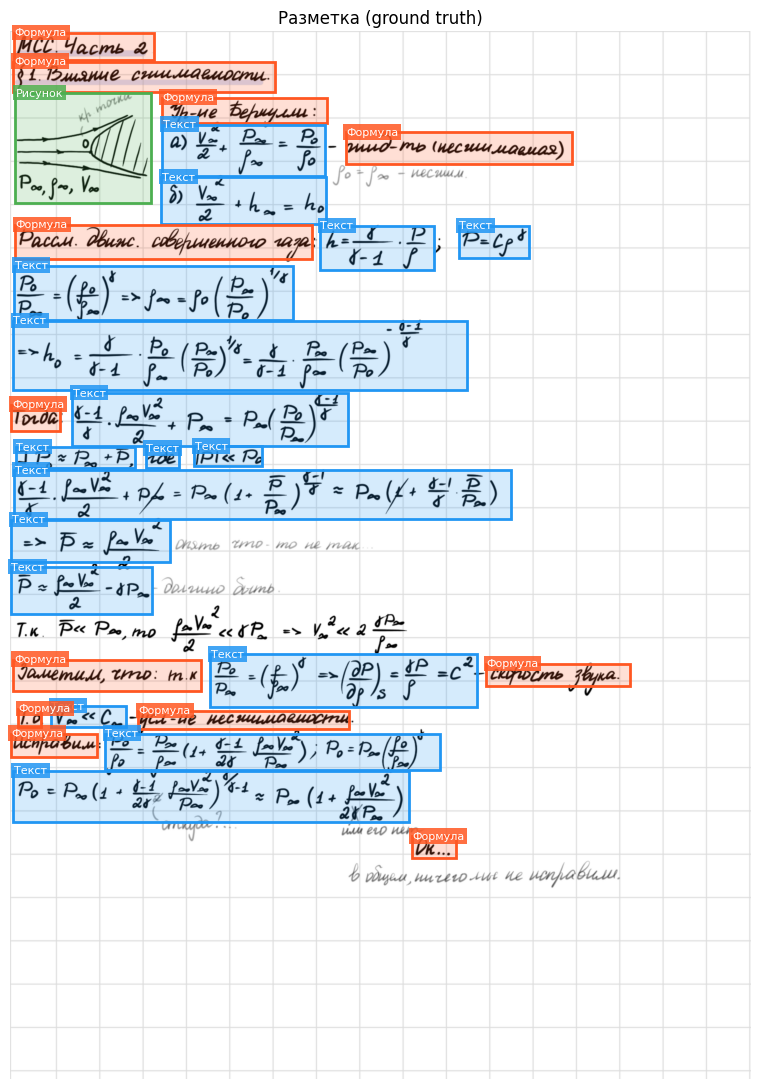

In [10]:


# -- Визуализация разметки -------------------------------------
img = Image.open(IMAGE_PATH)
W, H = img.size
fig, ax = plt.subplots(figsize=(8, 11))
ax.imshow(img); ax.axis("off"); ax.set_title("Разметка (ground truth)")
with open(label_txt) as f:
    for line in f:
        p = line.strip().split()
        if len(p) < 5: continue
        cls = int(p[0])
        xc, yc, w, h = map(float, p[1:5])
        x0, y0 = (xc - w/2)*W, (yc - h/2)*H
        color = CLASS_COLORS[cls]
        ax.add_patch(mpatches.Rectangle((x0,y0), w*W, h*H,
            linewidth=2, edgecolor=color, facecolor=color+"30"))
        ax.text(x0+3, y0+14, CLASS_NAMES[cls], fontsize=8, color="white",
                bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"))
plt.tight_layout(); plt.show()

Ultralytics 8.4.19 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10821MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset_test/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=lecture_test3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

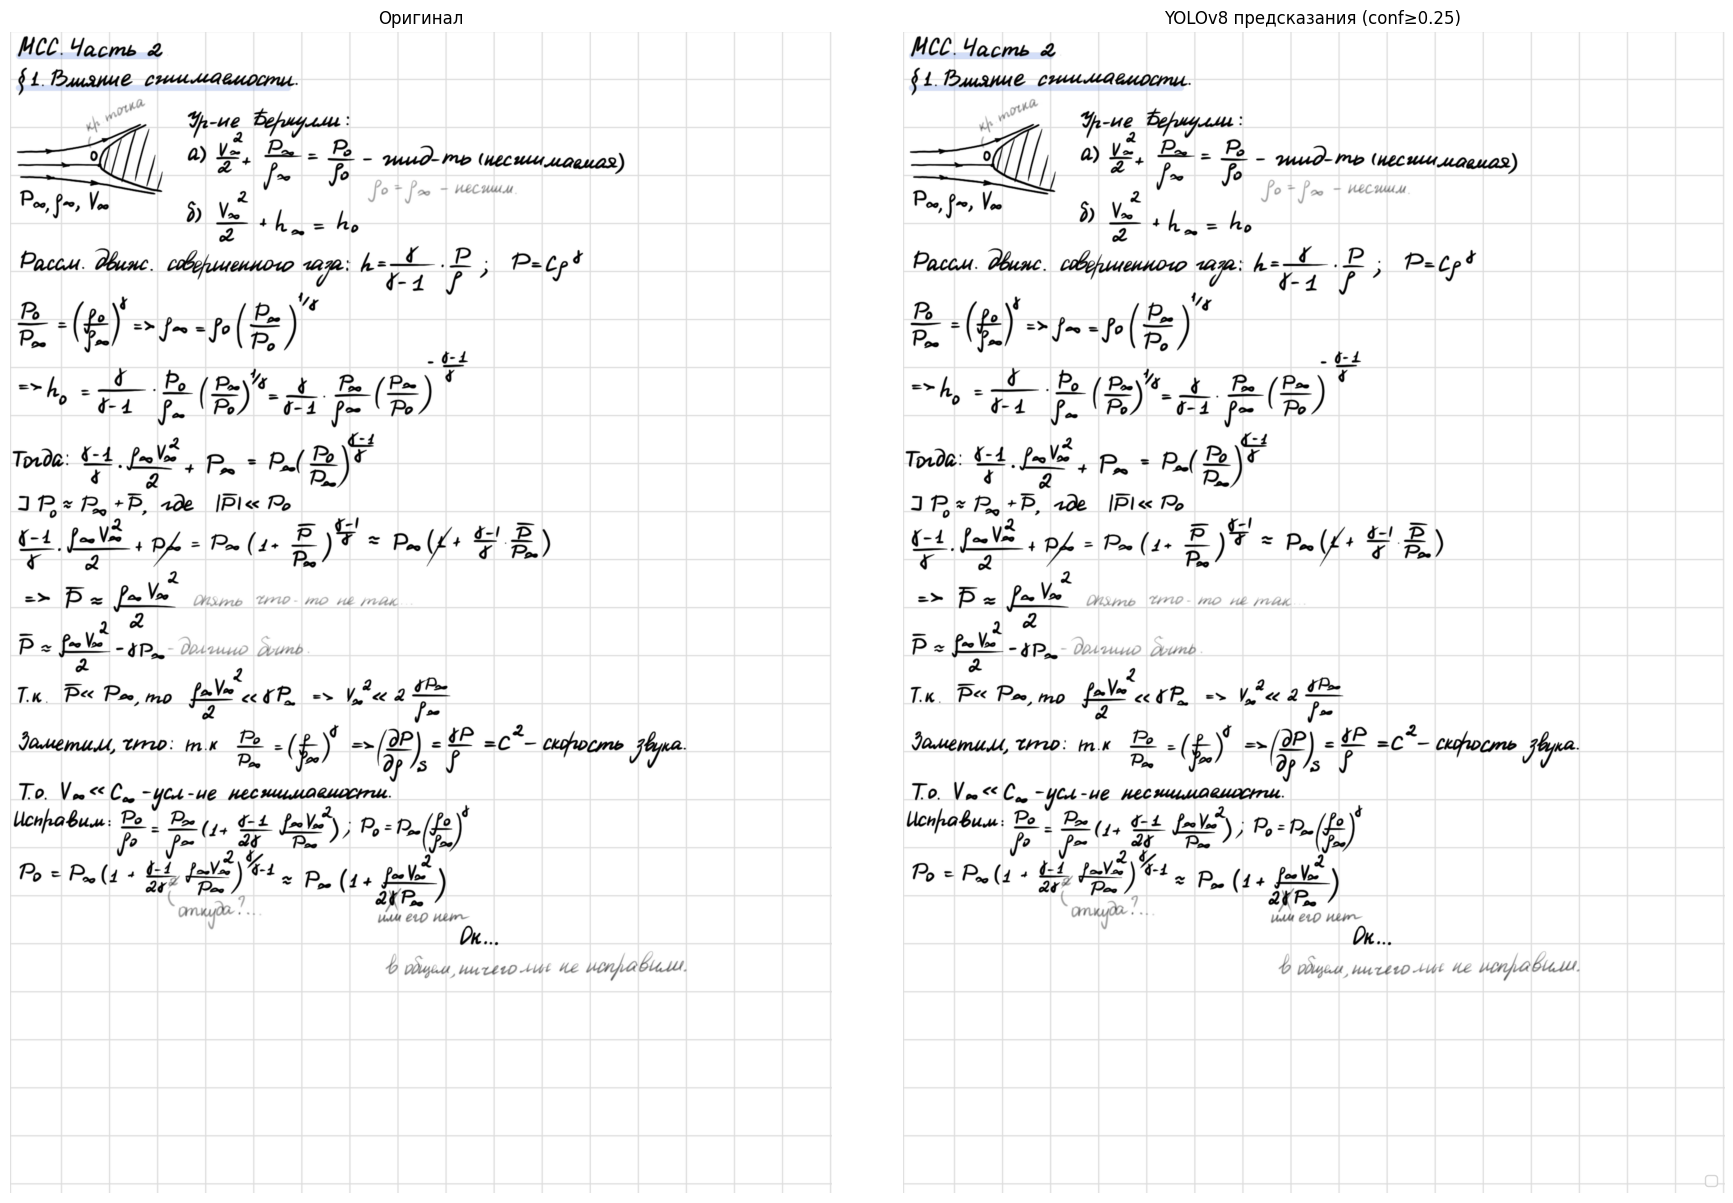

Найдено объектов: 0


In [ ]:
# -- Обучение --------------------------------------------------
model = YOLO(f"{MODEL_SIZE}.pt")
result = model.train(
    data=str(yaml_path), epochs=EPOCHS, imgsz=IMG_SIZE,
    batch=1, device=0, workers=0,
    project="yolo_runs", name="lecture_test",
    fliplr=0.0, flipud=0.0, mosaic=0.0,
    patience=20, augment = False,
)

# -- Ищем веса автоматически -----------------------------------
best_path = Path(result.save_dir) / "weights" / "best.pt"
if not best_path.exists():
    best_path = Path(result.save_dir) / "weights" / "last.pt"
print(f"Загружаем модель: {best_path}")

# -- Тест на том же изображении --------------------------------
best = YOLO(str(best_path))
pred = best.predict(str(IMAGE_PATH), imgsz=IMG_SIZE, conf=0.01)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))
ax1.imshow(img); ax1.set_title("Оригинал"); ax1.axis("off")
ax2.imshow(img); ax2.set_title(f"YOLOv8 предсказания (conf≥0.25)"); ax2.axis("off")

seen = {}
for box in pred.boxes:
    cls = int(box.cls[0]); conf = float(box.conf[0])
    x0,y0,x1,y1 = box.xyxy[0].tolist()
    color = CLASS_COLORS[cls]
    ax2.add_patch(mpatches.Rectangle((x0,y0), x1-x0, y1-y0,
        linewidth=2, edgecolor=color, facecolor=color+"30"))
    ax2.text(x0+4, y0+16, f"{CLASS_NAMES[cls]} {conf:.2f}", fontsize=8, color="white",
             bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"))
    seen[CLASS_NAMES[cls]] = color

ax2.legend(handles=[mpatches.Patch(color=c, label=l) for l,c in seen.items()],
           loc="lower right", fontsize=10)
plt.tight_layout(); plt.show()

counts = Counter(CLASS_NAMES[int(b.cls[0])] for b in pred.boxes)
print(f"Найдено объектов: {len(pred.boxes)}")
for name, cnt in counts.most_common():
    print(f"  {name}: {cnt}")

In [19]:
# Проверка: печатаем первые 3 строки label файла
with open(label_txt) as f:
    lines = f.readlines()
print(f"Строк в разметке: {len(lines)}")
print("Первые 3 строки:")
for l in lines[:3]:
    print(repr(l))

Строк в разметке: 30
Первые 3 строки:
'2 0.10001184534191036 0.014518366547555577 0.18937604175008121 0.02581042941787658\n'
'2 0.18139030504977655 0.043286241002897186 0.3536540538706335 0.028499015815572067\n'
'1 0.0984907526370904 0.1115763355043623 0.18329167093080145 0.10485486951012363\n'
